# PART A

In [1]:
import os
from pathlib import Path
import random

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Audio, display

In [2]:
DATASET_DIR = Path("dataset")

In [3]:
classes = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])

print(classes)

['bed', 'bird', 'cat', 'dog']


In [4]:
dataset_info = []

for cls in classes:

    files = list((DATASET_DIR / cls).glob("*.wav"))

    total_duration = 0
    sample_rate = None

    for f in files:

        y, sr = librosa.load(f, sr=None)

        sample_rate = sr

        total_duration += len(y) / sr

    dataset_info.append({

        "Class": cls,

        "Samples": len(files),

        "Duration (s)": round(total_duration,2),

        "Sample Rate": sample_rate

    })

dataset_df = pd.DataFrame(dataset_info)

dataset_df

,Class,Samples,Duration (s),Sample Rate
0,bed,1713,1681.30,16000
1,bird,1731,1697.91,16000
2,cat,1733,1700.02,16000
3,dog,1746,1715.79,16000


In [5]:
summary = pd.DataFrame({

    "Property":[

        "Number of classes",

        "Total samples",

        "Average Sample Rate"

    ],

    "Value":[

        len(classes),

        dataset_df["Samples"].sum(),

        int(dataset_df["Sample Rate"].mode()[0])

    ]

})

summary

,Property,Value
0,Number of classes,4
1,Total samples,6923
2,Average Sample Rate,16000


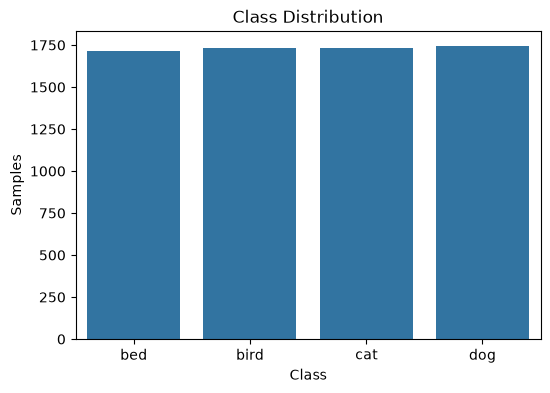

In [6]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=dataset_df,
    x="Class",
    y="Samples"
)

plt.title("Class Distribution")

plt.show()

In [7]:
example_files = {}

for cls in classes:

    example_files[cls] = random.choice(
        list((DATASET_DIR/cls).glob("*.wav"))
    )

In [8]:
for cls in classes:

    print(cls)

    display(Audio(str(example_files[cls])))

bed


bird


cat


dog


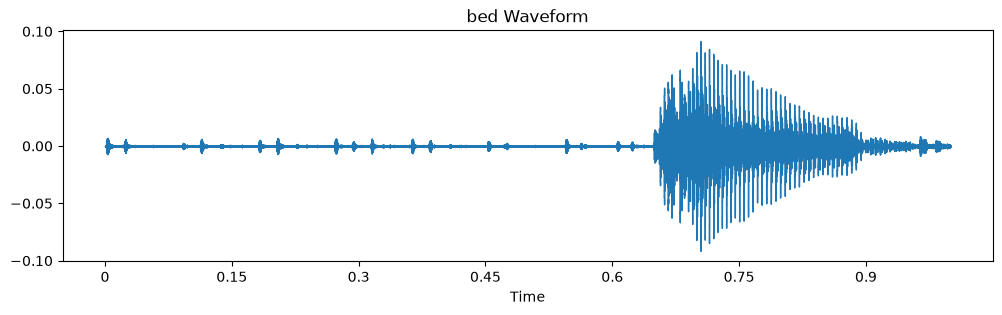

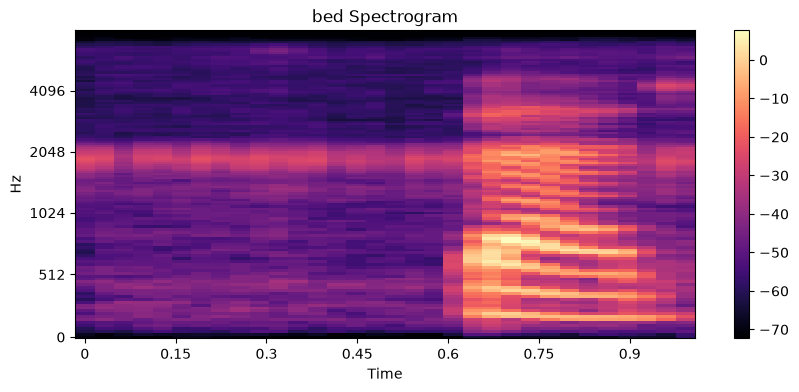

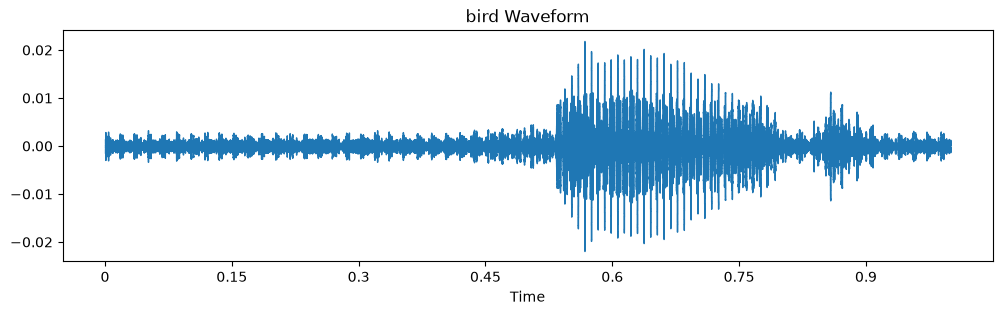

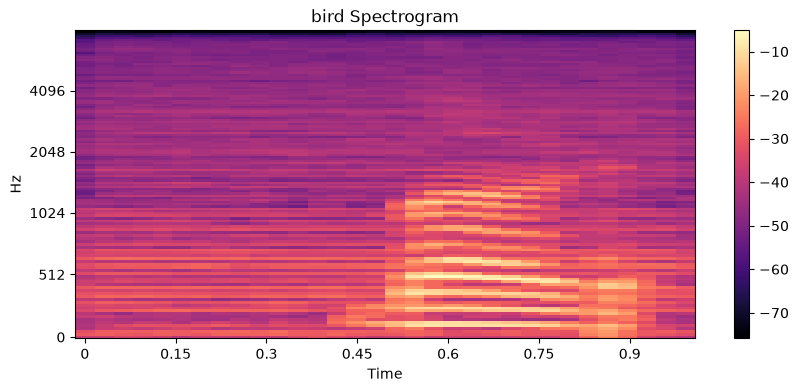

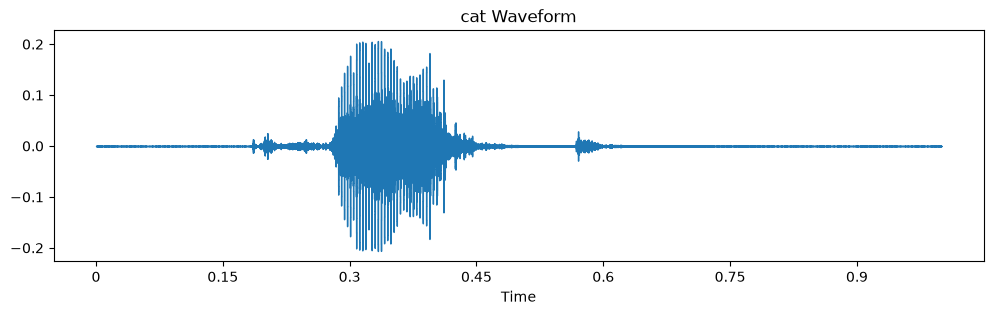

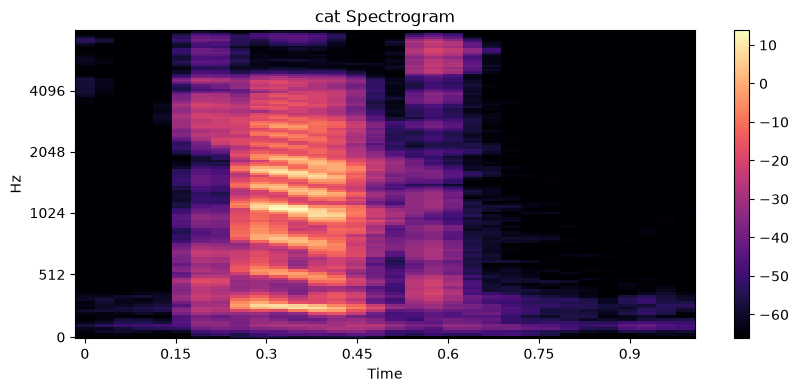

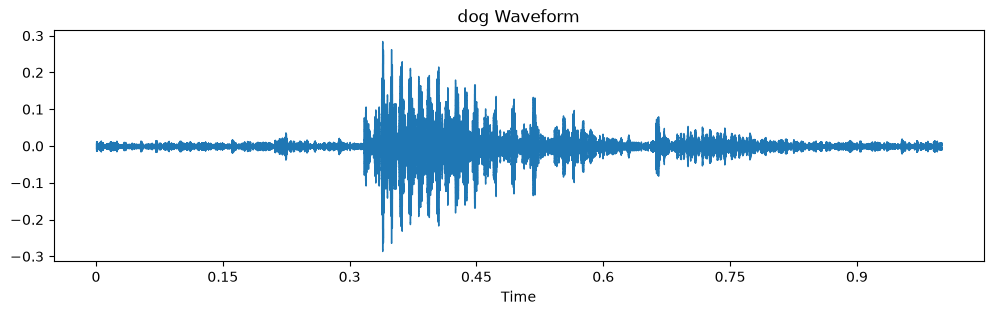

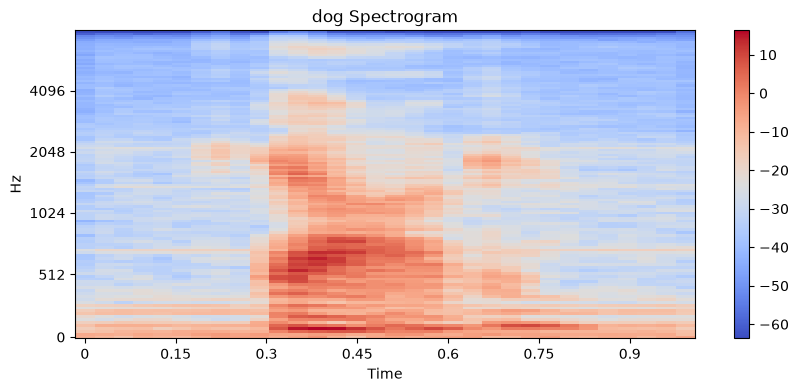

In [9]:
for cls in classes:

    path = example_files[cls]

    y, sr = librosa.load(path, sr=None)

    plt.figure(figsize=(12,3))

    librosa.display.waveshow(
        y,
        sr=sr
    )

    plt.title(f"{cls} Waveform")

    plt.show()

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr
    )

    mel_db = librosa.power_to_db(mel)

    plt.figure(figsize=(10,4))

    librosa.display.specshow(

        mel_db,

        sr=sr,

        x_axis="time",

        y_axis="mel"

    )

    plt.title(f"{cls} Spectrogram")

    plt.colorbar()

    plt.show()

In [10]:
class AudioPreprocessor:

    def __init__(

        self,

        sr=16000,

        n_mels=64,

        n_fft=1024,

        hop_length=512,

        target_duration=4.0

    ):

        self.sr = sr

        self.n_mels = n_mels

        self.n_fft = n_fft

        self.hop_length = hop_length

        self.target_samples = int(sr*target_duration)

    def load_and_resample(self,path):

        y,sr = librosa.load(

            path,

            sr=None,

            mono=True

        )

        if sr != self.sr:

            y = librosa.resample(

                y,

                orig_sr=sr,

                target_sr=self.sr

            )

        return y

    def pad_or_truncate(self,y):

        if len(y) < self.target_samples:

            y = np.pad(

                y,

                (0,self.target_samples-len(y))

            )

        else:

            y = y[:self.target_samples]

        return y

    def extract_mel_spectrogram(self,y):

        mel = librosa.feature.melspectrogram(

            y=y,

            sr=self.sr,

            n_fft=self.n_fft,

            hop_length=self.hop_length,

            n_mels=self.n_mels

        )

        mel = librosa.power_to_db(

            mel,

            ref=np.max

        )

        mel = mel[np.newaxis,:,:]

        return mel.astype(np.float32)

    def process(self,path):

        y = self.load_and_resample(path)

        y = self.pad_or_truncate(y)

        mel = self.extract_mel_spectrogram(y)

        return mel

In [11]:
pre = AudioPreprocessor()

sample = example_files["bird"]

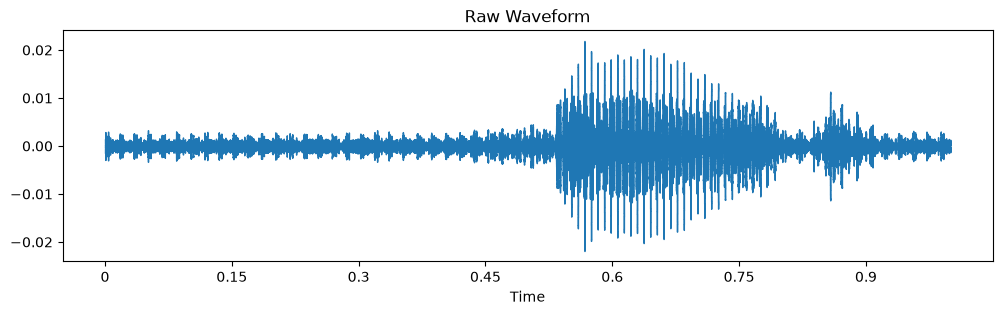

In [12]:
raw, raw_sr = librosa.load(sample, sr=None)

plt.figure(figsize=(12,3))

librosa.display.waveshow(raw, sr=raw_sr)

plt.title("Raw Waveform")

plt.show()

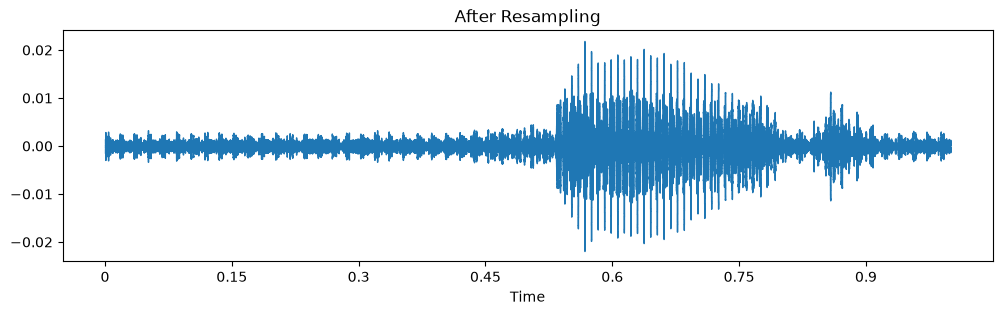

In [13]:
resampled = pre.load_and_resample(sample)

plt.figure(figsize=(12,3))

librosa.display.waveshow(

    resampled,

    sr=16000

)

plt.title("After Resampling")

plt.show()

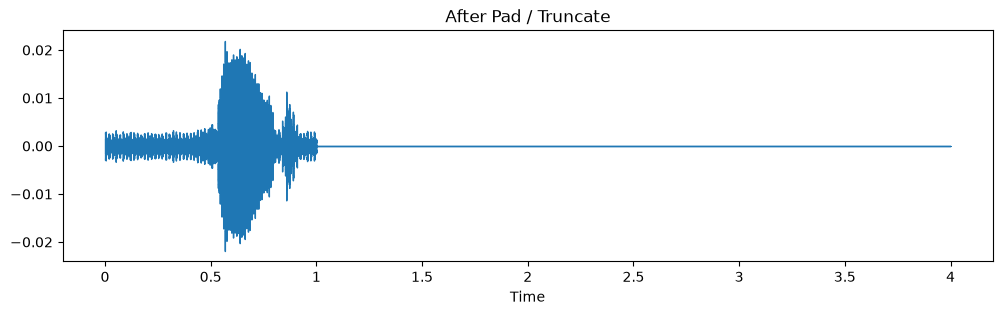

In [14]:
fixed = pre.pad_or_truncate(resampled)

plt.figure(figsize=(12,3))

librosa.display.waveshow(

    fixed,

    sr=16000

)

plt.title("After Pad / Truncate")

plt.show()

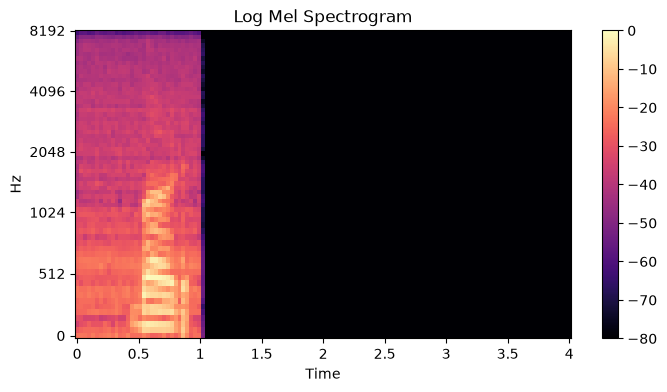

CNN Input Shape: (1, 64, 126)


In [15]:
mel = pre.extract_mel_spectrogram(fixed)

plt.figure(figsize=(8,4))

librosa.display.specshow(

    mel.squeeze(),

    sr=16000,

    x_axis="time",

    y_axis="mel"

)

plt.colorbar()

plt.title("Log Mel Spectrogram")

plt.show()

print("CNN Input Shape:", mel.shape)

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [17]:
DATASET_DIR = Path("dataset")

file_list = []
labels = []

class_to_idx = {
    cls: idx
    for idx, cls in enumerate(sorted(classes))
}

idx_to_class = {
    v: k
    for k, v in class_to_idx.items()
}

for cls in classes:

    for file in (DATASET_DIR/cls).glob("*.wav"):

        file_list.append(str(file))
        labels.append(class_to_idx[cls])

print("Total samples:", len(file_list))

Total samples: 6923


In [18]:
train_files, test_files, train_labels, test_labels = train_test_split(

    file_list,

    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels

)

train_files, val_files, train_labels, val_labels = train_test_split(

    train_files,

    train_labels,

    test_size=0.2,

    random_state=42,

    stratify=train_labels

)

print(len(train_files))
print(len(val_files))
print(len(test_files))

4430
1108
1385


In [19]:
class AudioDataset(Dataset):

    def __init__(

        self,

        file_list,

        labels,

        preprocessor,

        augment=None

    ):

        self.file_list = file_list
        self.labels = labels
        self.preprocessor = preprocessor
        self.augment = augment

    def __len__(self):

        return len(self.file_list)

    def __getitem__(self, idx):

        spec = self.preprocessor.process(

            self.file_list[idx]

        )

        spec = torch.tensor(spec)

        if self.augment is not None:

            spec = self.augment(spec)

        label = torch.tensor(

            self.labels[idx],

            dtype=torch.long

        )

        return spec, label

In [20]:
preprocessor = AudioPreprocessor()

train_dataset = AudioDataset(

    train_files,

    train_labels,

    preprocessor

)

val_dataset = AudioDataset(

    val_files,

    val_labels,

    preprocessor

)

test_dataset = AudioDataset(

    test_files,

    test_labels,

    preprocessor

)

In [21]:
train_loader = DataLoader(

    train_dataset,

    batch_size=16,

    shuffle=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=16,

    shuffle=False

)

test_loader = DataLoader(

    test_dataset,

    batch_size=16,

    shuffle=False

)

In [22]:
spec, label = train_dataset[0]

print(spec.shape)

torch.Size([1, 64, 126])


In [23]:
class AudioCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64,128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,num_classes)

        )

    def forward(self,x):

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x

In [24]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

device

device(type='cpu')

In [26]:
model = AudioCNN(

    num_classes=len(classes)

).to(device)

In [27]:
criterion = nn.CrossEntropyLoss()

In [28]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

In [29]:
def train_one_epoch(loader):

    model.train()

    running_loss = 0

    predictions = []

    targets = []

    for x,y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        out = model(x)

        loss = criterion(out,y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pred = out.argmax(1)

        predictions.extend(

            pred.cpu().numpy()

        )

        targets.extend(

            y.cpu().numpy()

        )

    acc = accuracy_score(

        targets,

        predictions

    )

    return running_loss/len(loader), acc

In [30]:
def validate(loader):

    model.eval()

    running_loss = 0

    predictions = []

    targets = []

    with torch.no_grad():

        for x,y in loader:

            x = x.to(device)
            y = y.to(device)

            out = model(x)

            loss = criterion(out,y)

            running_loss += loss.item()

            pred = out.argmax(1)

            predictions.extend(

                pred.cpu().numpy()

            )

            targets.extend(

                y.cpu().numpy()

            )

    acc = accuracy_score(

        targets,

        predictions

    )

    return running_loss/len(loader), acc

In [31]:
epochs = 20

train_loss = []
val_loss = []

train_acc = []
val_acc = []

for epoch in range(epochs):

    tl, ta = train_one_epoch(

        train_loader

    )

    vl, va = validate(

        val_loader

    )

    train_loss.append(tl)
    val_loss.append(vl)

    train_acc.append(ta)
    val_acc.append(va)

    print(

        f"Epoch {epoch+1}/{epochs}"

        f"  Train Loss {tl:.4f}"

        f"  Val Loss {vl:.4f}"

        f"  Train Acc {ta:.4f}"

        f"  Val Acc {va:.4f}"

    )

Epoch 1/20  Train Loss 1.2718  Val Loss 1.2095  Train Acc 0.3725  Val Acc 0.4043
Epoch 2/20  Train Loss 1.0522  Val Loss 1.0134  Train Acc 0.5093  Val Acc 0.5505
Epoch 3/20  Train Loss 0.9632  Val Loss 1.1782  Train Acc 0.5702  Val Acc 0.4495
Epoch 4/20  Train Loss 0.8320  Val Loss 2.1904  Train Acc 0.6688  Val Acc 0.3069
Epoch 5/20  Train Loss 0.6902  Val Loss 1.0117  Train Acc 0.7316  Val Acc 0.5776
Epoch 6/20  Train Loss 0.6204  Val Loss 1.0453  Train Acc 0.7679  Val Acc 0.5866
Epoch 7/20  Train Loss 0.5533  Val Loss 0.5817  Train Acc 0.7973  Val Acc 0.7861
Epoch 8/20  Train Loss 0.4917  Val Loss 1.8068  Train Acc 0.8228  Val Acc 0.4152
Epoch 9/20  Train Loss 0.4498  Val Loss 0.4463  Train Acc 0.8332  Val Acc 0.8421
Epoch 10/20  Train Loss 0.3978  Val Loss 0.5192  Train Acc 0.8573  Val Acc 0.8096
Epoch 11/20  Train Loss 0.3838  Val Loss 0.4930  Train Acc 0.8609  Val Acc 0.8231
Epoch 12/20  Train Loss 0.3292  Val Loss 0.7666  Train Acc 0.8885  Val Acc 0.7392
Epoch 13/20  Train Loss 0

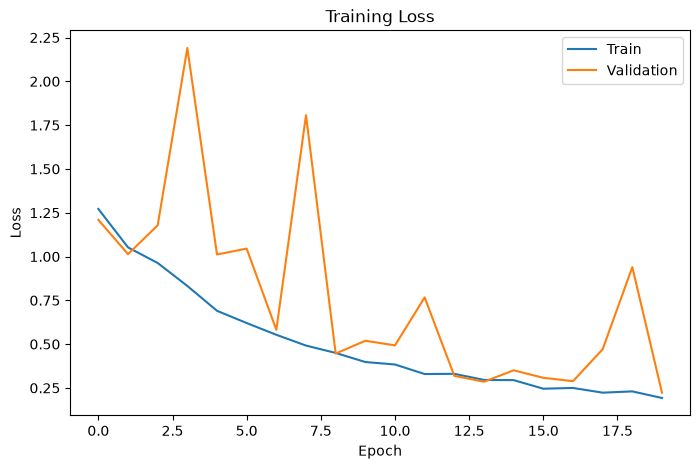

In [32]:
plt.figure(figsize=(8,5))

plt.plot(

    train_loss,

    label="Train"

)

plt.plot(

    val_loss,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

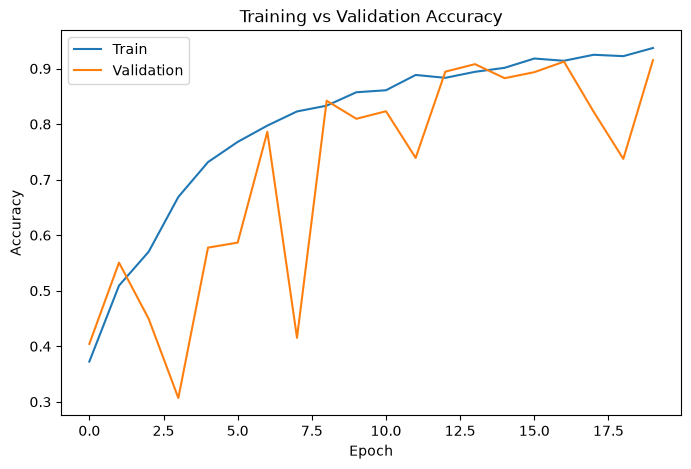

In [33]:
plt.figure(figsize=(8,5))

plt.plot(

    train_acc,

    label="Train"

)

plt.plot(

    val_acc,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

In [34]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import seaborn as sns

In [35]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        output = model(x)

        pred = output.argmax(1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

In [36]:
test_acc = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print("Test Accuracy :", test_acc)
print("Macro Precision :", precision)
print("Macro Recall :", recall)
print("Macro F1 :", f1)

Test Accuracy : 0.9032490974729241
Macro Precision : 0.9093928900915149
Macro Recall : 0.9035443332259292
Macro F1 : 0.9026764284921291


In [37]:
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

         bed       0.82      0.96      0.89       343
        bird       0.92      0.88      0.90       346
         cat       0.92      0.97      0.94       347
         dog       0.98      0.80      0.88       349

    accuracy                           0.90      1385
   macro avg       0.91      0.90      0.90      1385
weighted avg       0.91      0.90      0.90      1385



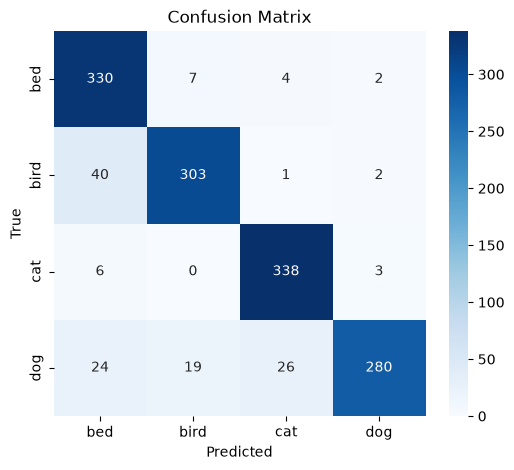

In [38]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

In [39]:
model.eval()

predictions = []

with torch.no_grad():

    for idx in range(len(test_dataset)):

        spec, label = test_dataset[idx]

        x = spec.unsqueeze(0).to(device)

        output = model(x)

        pred = output.argmax(1).item()

        predictions.append({

            "spec": spec,

            "true": label.item(),

            "pred": pred

        })

In [40]:
correct = []

for p in predictions:

    if p["true"] == p["pred"]:

        correct.append(p)

print(len(correct))

1251


In [41]:
incorrect = []

for p in predictions:

    if p["true"] != p["pred"]:

        incorrect.append(p)

print(len(incorrect))

134


# PART B

In [43]:
import random
import torch

class SpecAugment:

    def __init__(self,
                 freq_mask_param=15,
                 time_mask_param=35,
                 num_freq_masks=2,
                 num_time_masks=2):

        self.F = freq_mask_param
        self.T = time_mask_param
        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks

    def freq_mask(self, spec):

        _, n_mels, _ = spec.shape

        f = random.randint(0, self.F)

        if f == 0:
            return spec

        f0 = random.randint(0, max(0, n_mels-f))

        spec[:, f0:f0+f, :] = 0

        return spec

    def time_mask(self, spec):

        _, _, n_frames = spec.shape

        t = random.randint(0, self.T)

        if t == 0:
            return spec

        t0 = random.randint(0, max(0, n_frames-t))

        spec[:, :, t0:t0+t] = 0

        return spec

    def __call__(self, spec):

        spec = spec.clone()

        for _ in range(self.num_freq_masks):
            spec = self.freq_mask(spec)

        for _ in range(self.num_time_masks):
            spec = self.time_mask(spec)

        return spec

In [55]:
augment = SpecAugment(
    freq_mask_param=5,
    time_mask_param=5,
    num_freq_masks=2,
    num_time_masks=2
)

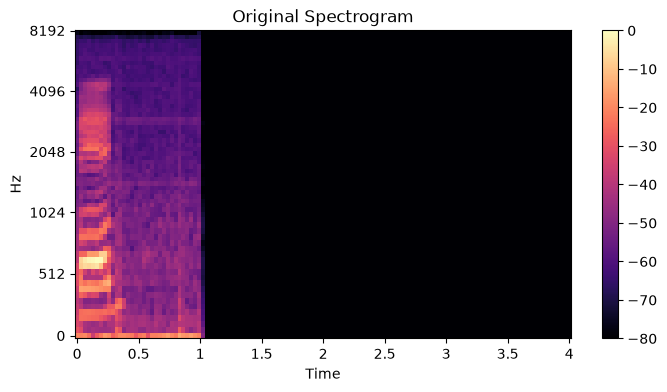

In [56]:
spec, label = train_dataset[0]

plt.figure(figsize=(8,4))

librosa.display.specshow(
    spec.squeeze().numpy(),
    sr=16000,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()
plt.title("Original Spectrogram")
plt.show()

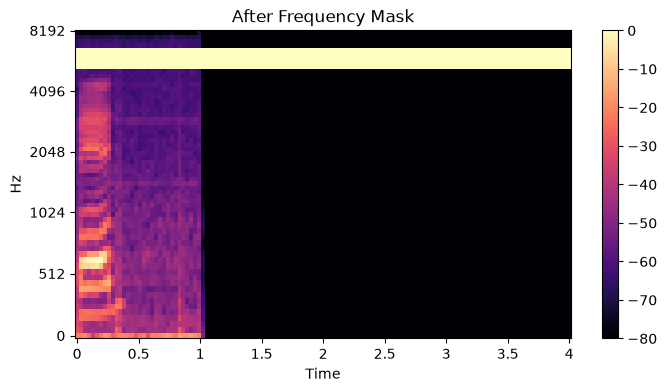

In [60]:
freq_only = spec.clone()

freq_only = augment.freq_mask(freq_only)

plt.figure(figsize=(8,4))

librosa.display.specshow(
    freq_only.squeeze().numpy(),
    sr=16000,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("After Frequency Mask")

plt.show()

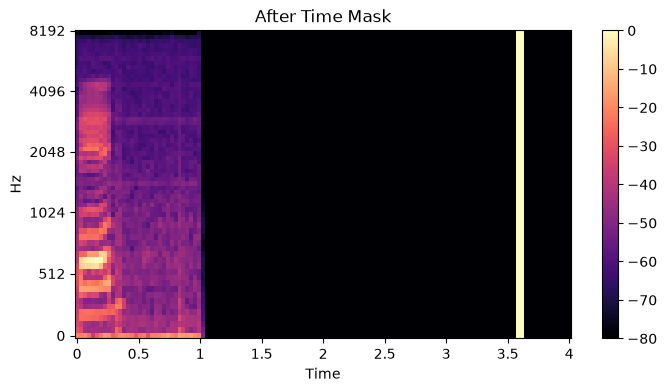

In [66]:
time_only = spec.clone()

time_only = augment.time_mask(time_only)

plt.figure(figsize=(8,4))

librosa.display.specshow(
    time_only.squeeze().numpy(),
    sr=16000,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("After Time Mask")

plt.show()

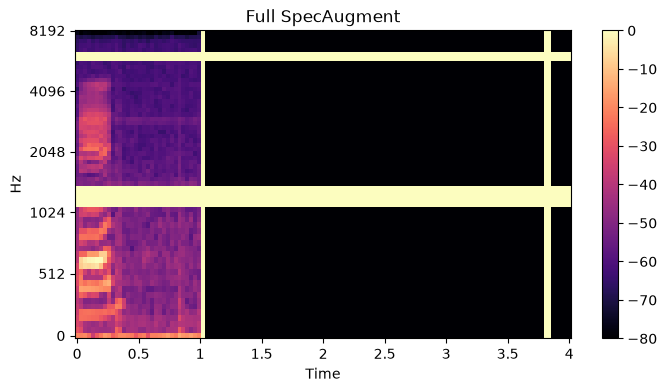

In [67]:
augmented = augment(spec)

plt.figure(figsize=(8,4))

librosa.display.specshow(
    augmented.squeeze().numpy(),
    sr=16000,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Full SpecAugment")

plt.show()

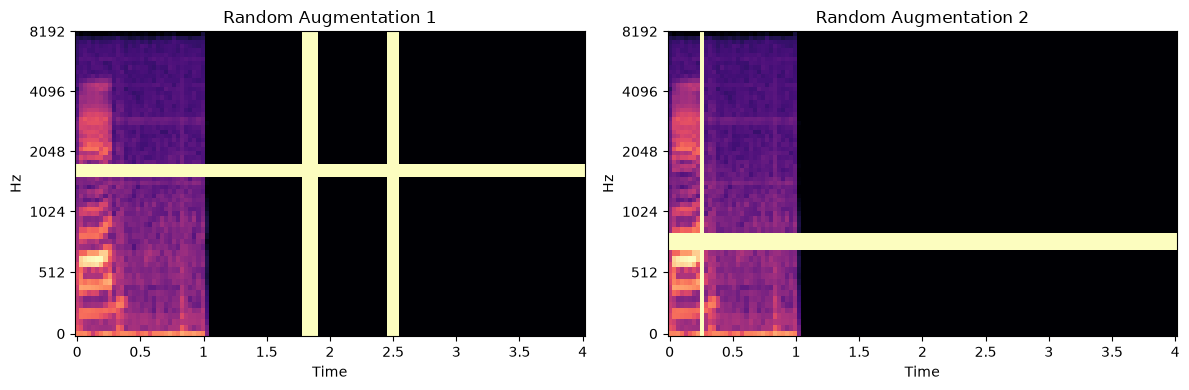

In [68]:
plt.figure(figsize=(12,4))

for i in range(2):

    plt.subplot(1,2,i+1)

    aug = augment(spec)

    librosa.display.specshow(
        aug.squeeze().numpy(),
        sr=16000,
        x_axis="time",
        y_axis="mel"
    )

    plt.title(f"Random Augmentation {i+1}")

plt.tight_layout()

plt.show()

In [69]:
train_dataset_aug = AudioDataset(
    train_files,
    train_labels,
    preprocessor,
    augment=augment
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=16,
    shuffle=True
)

In [70]:
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [71]:
model_aug = AudioCNN(len(classes)).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=0.001
)

In [72]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    preds = []
    targets = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        out = model(x)

        loss = criterion(out, y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds.extend(out.argmax(1).cpu().numpy())
        targets.extend(y.cpu().numpy())

    acc = accuracy_score(targets, preds)

    return running_loss/len(loader), acc


def validate(model, loader):

    model.eval()

    running_loss = 0

    preds = []
    targets = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            out = model(x)

            loss = criterion(out, y)

            running_loss += loss.item()

            preds.extend(out.argmax(1).cpu().numpy())
            targets.extend(y.cpu().numpy())

    acc = accuracy_score(targets, preds)

    return running_loss/len(loader), acc

In [73]:
epochs = 20

train_loss_aug = []
val_loss_aug = []

train_acc_aug = []
val_acc_aug = []

for epoch in range(epochs):

    tl, ta = train_one_epoch(model_aug, train_loader_aug)

    vl, va = validate(model_aug, val_loader)

    train_loss_aug.append(tl)
    val_loss_aug.append(vl)

    train_acc_aug.append(ta)
    val_acc_aug.append(va)

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Train Loss:{tl:.4f} "
        f"Val Loss:{vl:.4f} "
        f"Train Acc:{ta:.4f} "
        f"Val Acc:{va:.4f}"
    )

Epoch 1/20 Train Loss:1.3913 Val Loss:1.3877 Train Acc:0.2499 Val Acc:0.2509
Epoch 2/20 Train Loss:1.3783 Val Loss:1.3961 Train Acc:0.2797 Val Acc:0.2509
Epoch 3/20 Train Loss:1.3339 Val Loss:1.6691 Train Acc:0.3354 Val Acc:0.2527
Epoch 4/20 Train Loss:1.2395 Val Loss:1.7985 Train Acc:0.4068 Val Acc:0.2545
Epoch 5/20 Train Loss:1.1645 Val Loss:4.6873 Train Acc:0.4400 Val Acc:0.2500
Epoch 6/20 Train Loss:1.1413 Val Loss:1.0806 Train Acc:0.4472 Val Acc:0.4648
Epoch 7/20 Train Loss:1.1118 Val Loss:1.6865 Train Acc:0.4628 Val Acc:0.2753
Epoch 8/20 Train Loss:1.0903 Val Loss:1.6935 Train Acc:0.4695 Val Acc:0.2960
Epoch 9/20 Train Loss:1.0832 Val Loss:1.3420 Train Acc:0.4777 Val Acc:0.3592
Epoch 10/20 Train Loss:1.0780 Val Loss:0.9777 Train Acc:0.4869 Val Acc:0.5487
Epoch 11/20 Train Loss:1.0570 Val Loss:1.0623 Train Acc:0.4910 Val Acc:0.4612
Epoch 12/20 Train Loss:1.0399 Val Loss:0.9589 Train Acc:0.4932 Val Acc:0.5767
Epoch 13/20 Train Loss:1.0216 Val Loss:1.1814 Train Acc:0.5117 Val Acc:0.

In [74]:
model_aug.eval()

y_true_aug = []
y_pred_aug = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        out = model_aug(x)

        pred = out.argmax(1)

        y_true_aug.extend(y.cpu().numpy())
        y_pred_aug.extend(pred.cpu().numpy())

In [75]:
test_acc_aug = accuracy_score(y_true_aug, y_pred_aug)

precision_aug = precision_score(
    y_true_aug,
    y_pred_aug,
    average="macro"
)

recall_aug = recall_score(
    y_true_aug,
    y_pred_aug,
    average="macro"
)

f1_aug = f1_score(
    y_true_aug,
    y_pred_aug,
    average="macro"
)

print(classification_report(
    y_true_aug,
    y_pred_aug,
    target_names=classes
))

              precision    recall  f1-score   support

         bed       0.60      0.38      0.47       343
        bird       0.49      0.77      0.60       346
         cat       0.94      0.86      0.90       347
         dog       0.58      0.51      0.54       349

    accuracy                           0.63      1385
   macro avg       0.65      0.63      0.63      1385
weighted avg       0.65      0.63      0.63      1385



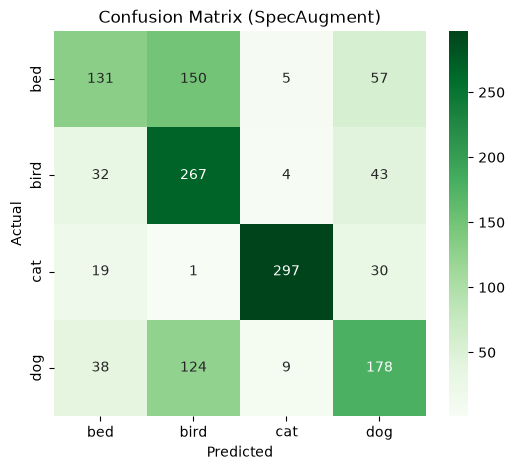

In [76]:
cm = confusion_matrix(y_true_aug, y_pred_aug)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Greens",
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SpecAugment)")

plt.show()

In [77]:
comparison = pd.DataFrame({

    "Metric":[
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],

    "Without SpecAugment":[
        test_acc,
        precision,
        recall,
        f1
    ],

    "With SpecAugment":[
        test_acc_aug,
        precision_aug,
        recall_aug,
        f1_aug
    ]

})

comparison

,Metric,Without SpecAugment,With SpecAugment
0,Test Accuracy,0.903249,0.630325
1,Macro Precision,0.909393,0.652213
2,Macro Recall,0.903544,0.629884
3,Macro F1,0.902676,0.626463


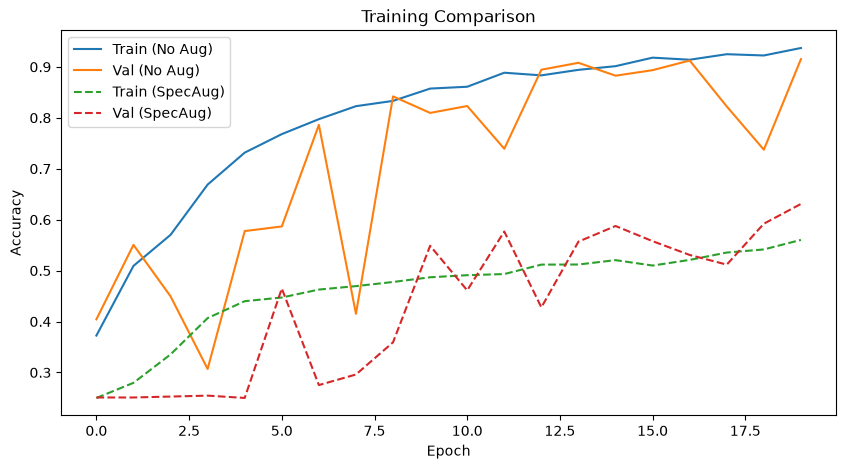

In [78]:
plt.figure(figsize=(10,5))

plt.plot(train_acc, label="Train (No Aug)")
plt.plot(val_acc, label="Val (No Aug)")

plt.plot(train_acc_aug, '--', label="Train (SpecAug)")
plt.plot(val_acc_aug, '--', label="Val (SpecAug)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Comparison")
plt.legend()
plt.show()